# Code for plots Fig. 2

In [1]:
# import libraries
import os,sys,inspect
import numpy as np
from scipy.stats import ttest_rel,wilcoxon
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from scipy.stats import friedmanchisquare
import warnings
warnings.filterwarnings("ignore")
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
%matplotlib inline

# import modules
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from behaviour import Logreg_coefs,Psychometric_curves,\
    get_performance_subject,get_stimuli_space
from data_import import Session,Trial
from utilities import format_boxplot, statistical_annotation, get_property,\
trainingpoint_short,trainingpoint_dict,normality_test,sphericity_test,\
format_axs,erf_psycho,get_experimental_timepoint,mle_fit_psycho


Calling training.py from module script:  behaviour.training
Calling day_statistics.py from module script:  behaviour.day_statistics
Calling helper_data.py from module script:  utilities.helper_data
Calling helper_tensor.py from module script:  utilities.helper_tensor
Calling helper_logreg.py from module script:  utilities.helper_logreg
Calling behaviour_import.py from module script:  data_import.behaviour_import
Please enter DataJoint username: root
Please enter DataJoint password: ········
Connecting root@localhost:3306
Calling recording_import.py from module script:  data_import.recording_import
Calling aligned_recording.py from module script:  data_import.aligned_recording
Calling validation_alignment.py from module script:  data_import.cell_registration
Calling cell_registration.py from module script:  data_import.cell_registration
CALLING dlc_video.py from module script:  data_import.dlc_video
Calling categories.py from module script:  design.categories
Calling helper_design.py fr

## Fig. 2A
Corresponds to schematic on psychometric fit parameters

## Fig. 2B
### Fraction of correct choices for first pair of stimuli throughout stages

n =  6
test:  AnovaRM
df =  3.0 15.0 F =  1.381 p =  0.287
test (assuming sphericity violated):  Friedman Rank Sum
 Q: 2.6000000000000085 p=  0.4574895468781821


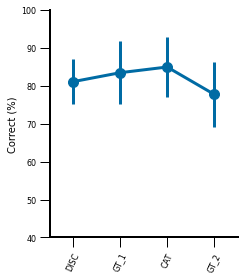

In [3]:
%matplotlib inline
def get_stickiness_init():
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    phase_labels = ['DISC','GT_1','CAT','GT_2']
    mode,stage,categoryset_id = trainingpoint_dict['gentest_2']
    entries_point = Session() & 'mode="%s"'%mode \
            & 'stage="%i"'%stage & 'categoryset_id="%i"'%categoryset_id
    animal_ids = get_property(entries_point,'animal_id')
    data_perf = np.zeros((len(animal_ids),len(phases)))
    print('n = ',len(animal_ids))
    for i,animal_id in enumerate(animal_ids):
        for j,phase in enumerate(phases):
            mode,stage,categoryset_id = trainingpoint_dict[phase]
            sessions = Session() & 'mode="%s"'%mode \
                & 'stage="%i"'%stage & 'categoryset_id="%i"'%categoryset_id \
                    & 'animal_id="%s"'%animal_id
            if len(sessions) == 0:
                data_perf[i,j] = np.nan
            else:
                dates = get_property(sessions,'date')[-2:]
                data_dates = []
                for date in dates:
                    trial_entries = Trial() & 'mode="%s"'%mode \
                        & 'stage="%i"'%stage & 'categoryset_id="%i"'%categoryset_id
                    trials_a = trial_entries & 'animal_id="%s"'%animal_id & 'date="%s"'%str(date) \
                        & 'stimulus_id="4652"' & 'trialtype="active"'
                    trials_b = trial_entries & 'animal_id="%s"'%animal_id & 'date="%s"'%str(date) \
                        & 'stimulus_id="9358"' & 'trialtype="active"'
                    nr_trials = len(trials_a) + len(trials_b)
                    
                    corr_a = trials_a & 'responsetype="correct"'
                    corr_b = trials_b & 'responsetype="correct"'
                    data_dates.append((len(corr_a)+len(corr_b))/nr_trials)
                data_perf[i,j] = np.mean(data_dates)*100
                
    test = 'AnovaRM'
    for i in range(len(phases)):
        data = data_perf[:,i]
        try:
            normality = normality_test(data)
        except:
            pass
    
        if not normality:
            print('Normality violated')
            test = 'Friedman Rank Sum test'
            break

    # check sphericity - variances of differences must be equal
    sphericity = sphericity_test(data_perf)
    if not sphericity:
        print('Sphericity violated')
        test = 'Friedman Rank Sum test'

    print('test: ','AnovaRM')
    phase_id = np.tile(np.arange(len(phases)), len(animal_ids))
    subject_id = np.repeat(np.arange(len(animal_ids)), len(phases))

    
    coef = {'Data':data_perf.flatten(),'Sub_id': subject_id,'cond': phase_id}
    coef = pd.DataFrame.from_dict(data = coef)
    aovrm = AnovaRM(coef, depvar = 'Data',subject = 'Sub_id', within=['cond'])
    res = aovrm.fit()
    coef = res.anova_table
    print('df = '+ ' '+ str(res.anova_table['Num DF'][0]) + ' ' + str(res.anova_table['Den DF'][0]), 'F = ' + ' ' + str(np.round(res.anova_table['F Value'][0],3)),'p = ' + ' '+ str(np.round(res.anova_table['Pr > F'][0],3)));

    print('test (assuming sphericity violated): ','Friedman Rank Sum')
    # friedman test
    data = data_perf.T # array by phases 
    assert data.shape[0] == len(phases)
    stat,p_val = friedmanchisquare(*data)
    print(' Q: '+ str(stat) + ' p= ',p_val)
    
# plot coefficients across training days
    fig,axs = plt.subplots()
    fig.set_figwidth(3.5)
    fig.set_figheight(4)
    m = np.mean(data_perf,axis=0)
    st = np.std(data_perf,axis=0)
    plt.errorbar(np.arange(0.5,len(phases)), m, yerr=st, fmt='o-',
                 linewidth=3,markersize=10)
    
    plt.ylim(40,100)
    plt.xlim(0,len(phases))
    plt.xticks(np.arange(0.5,len(phases)),phase_labels,rotation=65, fontsize = 16)

    plt.ylabel('Correct (%)')

    axs = format_axs(axs)
        
    plt.tight_layout()
    plt.show()
    
get_stickiness_init()

In [4]:
def real_predict_proba(input_values,known_metrics):
    sorted_metrics = list(known_metrics.items())
    values = list(known_metrics.keys())
    values.sort()
    probs = []
    for input_value in input_values:
        if input_value < values[0] or input_value > values[-1]:
            # If the input value is outside the range of known metrics
            if input_value < 0:
                lower_value, lower_prob = sorted_metrics[0]
                upper_value, upper_prob = sorted_metrics[1]
            else:
                lower_value, lower_prob = sorted_metrics[-2]
                upper_value, upper_prob = sorted_metrics[-1]
            slope = (upper_prob - lower_prob) / (upper_value - lower_value)
            intercept = lower_prob - slope * lower_value
            extrapolated_prob = slope * input_value + intercept
            probs.append(round(extrapolated_prob,4))
        else:
            # Find the two closest known input values
            for i in range(len(sorted_metrics) - 1):
                if sorted_metrics[i][0] <= input_value <= sorted_metrics[i + 1][0]:
                    # Interpolate probabilities
                    lower_value, lower_prob = sorted_metrics[i]
                    upper_value, upper_prob = sorted_metrics[i + 1]
                    ratio = (input_value - lower_value) / (upper_value - lower_value)
                    interpolated_prob = lower_prob + ratio * (upper_prob - lower_prob)
                    probs.append(round(interpolated_prob,4))
    
    return np.array(probs)


def get_dataset(test_stage):
    # returns dataset for artificial classifiers, training on training stage, and testing
    # for stimuli set in generalization tests
    if test_stage == 'gentest_1':
        train_stage = 'discrimination'
    elif test_stage == 'gentest_2':
        train_stage = 'categorization_4'
        
    stages = [train_stage,test_stage]
    Xs = []
    ys = []
    
    for stage in stages:
        mode,phase,categoryset_id = get_experimental_timepoint(stage)
        example_subject = 'BK4956_LR' # ground truth classification is the same for all subjects
        session_id = (Session()  \
                      & 'animal_id="%s"'%example_subject & 'mode="%s"'%mode \
                          & 'stage="%i"'%phase & 'categoryset_id="%i"'%categoryset_id).fetch('session_id')[-1]
        session_trials = Trial() \
            & 'animal_id="%s"'%example_subject & 'session_id="%i"'%session_id \
                & 'trialtype="active"'
                
        experiment = session_trials.fetch('name')[0]
        port_layout = session_trials.fetch('port_layout')[0]
        
        stimulus_id = list(session_trials.fetch('stimulus_id'))
        stimuli = [int(stimulus) for stimulus in stimulus_id]

        # get total stimuli space in experiment
        stimuli_space = get_stimuli_space(experiment)
        # normalize and log scale
        m = np.mean(np.log(stimuli_space))
        s = np.std(np.log(stimuli_space))
        norm_log_space = list((np.log(stimuli_space)-m)/s)
        stimuli_space = list(stimuli_space)
        # get stimuli set in stage(phase) in log norm scale
        X = np.array([norm_log_space[stimuli_space.index(stim)] for stim in stimuli])
        
        # get corresponding category assigned
        baited_port = session_trials.fetch('baited_port')
        y = [] 
        for i,stim in enumerate(stimuli):
            c = baited_port[i]
            # account for port layout - randomized across subjects
            if port_layout:
                c = 1-c
            y.append(c)
        
        Xs.append(X)
        ys.append(y)
        
    X_train, X_test = Xs
    y_train, y_test = ys
    return X_train, X_test, y_train, y_test


def get_groundtruth(stage):
    # get ground truth of stimuli (in log norm scale) in certain stage and corresponding category
    mode,phase,categoryset_id = get_experimental_timepoint(stage)
    # extract dataset 
    example_subject = 'BK4956_LR' # ground truth is the same for all animal subjects 
    session_id = (Session()  \
        & 'animal_id="%s"'%example_subject & 'mode="%s"'%mode \
            & 'stage="%i"'%phase & 'categoryset_id="%i"'%categoryset_id).fetch('session_id')[-1]
    session_trials = Trial() \
        & 'animal_id="%s"'%example_subject & 'session_id="%i"'%session_id \
            & 'trialtype="active"'
    
    experiment = session_trials.fetch('name')[0]
    port_layout = session_trials.fetch('port_layout')[0]
    
    stimulus_id = list(session_trials.fetch('stimulus_id'))
    stimuli = [int(stimulus) for stimulus in list(dict.fromkeys(stimulus_id))]
    stimuli.sort()
    # get total stimuli space in experiment
    stimuli_space = get_stimuli_space(experiment)
    # normalize and log scale
    m = np.mean(np.log(stimuli_space))
    s = np.std(np.log(stimuli_space))
    norm_log_space = list((np.log(stimuli_space)-m)/s)
    stimuli_space = list(stimuli_space)
    # get stimuli set in stage(phase) in log norm scale
    X = np.array([norm_log_space[stimuli_space.index(stim)] for stim in stimuli])
    
    # get corresponding category assigned
    baited_port = session_trials.fetch('baited_port')
    y = [] 
    for stim in stimuli:
        c = baited_port[stimulus_id.index(str(stim))]
        # account for port layout - randomized across subjects
        if port_layout:
            c = 1-c
        y.append(c)
        
    return X,y

def plot_decision_boundary(pred_func,axs,X):
    # Set min and max values and give it some padding
    x_min, x_max = X.min() - .5, X.max() + .5
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(x_min, x_max, h))
    # Predict the function value for the whole grid
    Z = pred_func(xx[0])
    # Z = pred_func(xx[0].reshape(-1,1))
    # # print('Z.shape',Z)
    # Z = Z[:,1]
    
    Z = np.tile(Z, len(xx)).reshape(len(xx),len(xx))

    axs.contourf(xx, yy, Z, cmap=plt.cm.RdBu,vmin=0,vmax=1)
    return axs

def plot_classifier_heatmap(dataset,metrics,data,score):
   
    X, y = dataset # log norm stimuli (x) , corresponding assigned category (y)
    
    x_min, x_max = X.min() - 0.5, X.max() + 0.5
    y_min, y_max = X.min() - 0.5, X.max() + 0.5
    y_plot = -0.25 
    
    cm_bright = ListedColormap(["tab:red","tab:blue"])
    
    pred_func = lambda x: real_predict_proba(x,metrics)
    
    # plot decision boundary according to metrics given
    fig,ax = plt.subplots()
    fig.set_figwidth(2.8)
    fig.set_figheight(4)
    plot_decision_boundary(pred_func,ax,X)
    
    # Plot the testing points
    ax.scatter(
        X,
        [y_plot] * len(X),
        c=y,
        cmap=cm_bright,
        edgecolors="white",
        s=64,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    #ax.set_title(plot_title,fontsize=14)
    ax.text(
        x_max - 2,
        y_min + 0.3,
        ("%.2f"%score + '$\%$').lstrip("0"),
        size=16,
        horizontalalignment="left",
        color='black',
    )
    print('score', score)

    # add the psychometrics 
    if data is not None:
        data,pars = data
        x, y = -2,0.2 # Bottom-left corner coordinates
        width, height = 1.9, 3 # Width and height of the box
        white_box = Rectangle((x, y), width, height, fill=True, color='white', edgecolor='white', linewidth=1)
        # Add the white box to the plot
        ax.add_patch(white_box)
        l, b, h, w = 0.2, 0.65, 0.2, 0.25 # Position and size of the small subplot
        ax2 = fig.add_axes([l, b, h, w], facecolor='white')
        
        # Plot on the small subplot
        ax2.plot(data[0], data[2], 'ko', mfc='k',markersize=3)
        ax2.axvline(x=0,linestyle='--',color='black',alpha=0.5)
        ax2.axhline(y=0.5,linestyle='--',color='black',alpha=0.5)
        ax2.set_ylim(0,1)
        ax2.plot(np.arange(data[0][0]-0.1, data[0][-1]+0.2, 0.1), 
                  erf_psycho(pars, np.arange(data[0][0]-0.1, data[0][-1]+0.2, 0.1)),'-k')

    plt.tight_layout()
    plt.show()
        

def plot_psychometric_map(animal_id,stage):
    
    psy_entry = Psychometric_curves() \
          & 'experimental_timepoint="%s"'%stage \
               & 'animal_id="%s"'%animal_id
    data = psy_entry.fetch('data')[0]
    pars = psy_entry.fetch('parameters')[0]
    
    metrics = {round(data[0][i],2):data[2][i] for i in range(len(data[0]))}
    

    performance = get_performance_subject(stage,animal_id)
    
    dataset = get_groundtruth(stage)
    
    data = data, pars
    plot_classifier_heatmap(dataset,metrics,data,performance)
    

## Fig. 2C
###  Example decision plots and psychometric fits for two artificial classifiers 

Nearest Neighbors
score 100.0


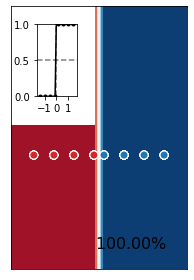

Linear SVM
score 92.05033958605443


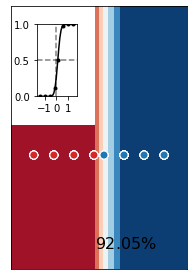

In [5]:
names = [
    "Nearest Neighbors",
    "Linear SVM"
]
classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42, probability=True)
]
X_train,X_test, y_train, y_test = get_dataset('gentest_1')
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)


for name, clf in zip(names, classifiers):
    print(name)
    clf.fit(X_train, y_train)
    pred_func = lambda x: clf.predict_proba(x)
    
    datax = np.unique(X_test) 
    datay = clf.predict_proba(np.unique(X_test).reshape(-1,1))[:,1]
    performance = []
    for test_0 in datay[:4]:
        performance.append(1-test_0)
    performance += list(datay[4:])
    score = np.mean(performance)*100
    
    nn = np.full((len(datax),), 10)
    data = np.vstack((datax, nn, datay))
    
    pars,_ = mle_fit_psycho(data, 'erf_psycho')
    
    metrics = {round(data[0][i],2):data[2][i] for i in range(len(data[0]))}
    
    plot_classifier_heatmap((X_test, y_test),metrics,(data,pars),score)

## Fig. 2D
### Decision plot and psychometric fit  for choices of example subject in generalization test 1 and in generalization test 2 

score 64.2


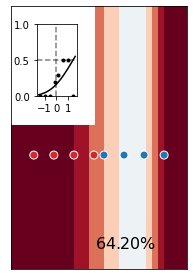

In [6]:
plot_psychometric_map('BK4936_L',stage='gentest_1')

score 75.82


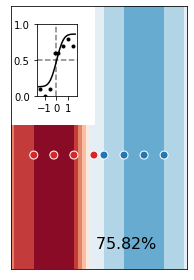

In [7]:
plot_psychometric_map('BK4936_L',stage='gentest_2')

## Fig. 2E
### Logistic regression coefficient for stimuli comparing testing and training stages

n =  6
test:  paired t-test
pvalue =  9.55960509012855e-07


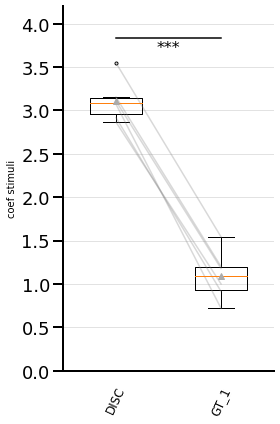

test:  paired t-test
pvalue =  0.0027914686755005883


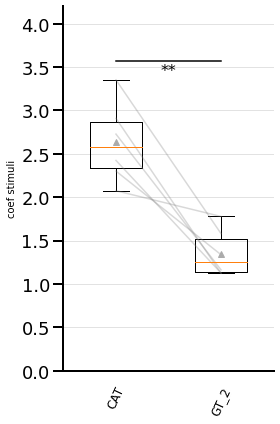

In [8]:

def plot_logregcoef_comparison(predicted_var,coef):
    # coef - 
    # get conditions to compare
    logreg_entries = Logreg_coefs() \
                & 'analysis_type="point"' & 'predicted_var="%s"'%predicted_var  
    trainingpoints = ['discrimination','gentest_1','categorization_4','gentest_2']
    # get subject entries that completed  condition training points
    entries_phase = logreg_entries & 'training_timepoint="gentest_2"'
    subjects = get_property(entries_phase,'animal_id')
    
    nr_subjects = len(subjects)
    print('n = ',nr_subjects)
        
    column_comparisons = [[0,1],[2,3]]

    coef_names = (logreg_entries & 'training_timepoint="%s"'%trainingpoints[0]).fetch('coef_names')[0]
    coef_idx = coef_names.tolist().index(coef)
    
    normality = True
    check = True
    test = 'paired t-test'
                
    for comparison in column_comparisons:
        
        conditions = [trainingpoints[comparison[0]],trainingpoints[comparison[1]]]
        column_labels = [trainingpoint_short[cond] for cond in conditions]
        
        datapoints = np.zeros((nr_subjects,2))
        for i,animal_id in enumerate(subjects):
            for j,condition in enumerate(conditions):
                coef_values = (logreg_entries  & 'training_timepoint="%s"'%condition \
                               & 'animal_id="%s"'%animal_id).fetch('coef_values')[0]
                datapoints[i,j] = coef_values[coef_idx]
                
        normality = True
        for i in range(2):
            try:
                check = normality_test(datapoints[:,i])
            except:
                pass
        
            if not check:
                normality = False
                test = 'Wilcoxon signed rank test'
                break
            
        # statistical test to reject null hypothesis-same mean
        if normality:
            result = ttest_rel(datapoints[:,0],datapoints[:,1],alternative="two-sided")
        else:
            result = wilcoxon(datapoints[:,0],datapoints[:,1],alternative="two-sided")
        print('test: ',test)
        print('pvalue = ',result.pvalue)
        
        # boxplot for each column
        fig, axs = plt.subplots()
        fig.set_figwidth(4)
        fig.set_figheight(6)
        
        axs = format_boxplot(axs,datapoints,column_labels,
                             y_label='coef %s'%coef,
                             paired=True)
        # add statistical annotation of comparisons made
        ymax = datapoints.max(); ymin = datapoints.min()
        axs,_ = statistical_annotation(axs,[[0,1]],
                                      [result.pvalue],ymax,ymin)
        
        axs.tick_params(axis='y',labelsize=18)
        axs.set_ylim(0,4.2)
        plt.tight_layout()
        plt.show()

plot_logregcoef_comparison('choices','stimuli')

## Fig. 2F
### Pair comparisons for fraction of correct responses between interpolation, first and extrapolation stimulis across train and corresponding test stages

GT_1
n =  6
t-test paired sample
Int  vs  First  pvalue ..:  0.000682794582987
Wilcoxon signed rank test
Int  vs  First  pvalue ..:  0.015625
t-test paired sample
First  vs  Ext  pvalue ..:  0.009679875880951
Wilcoxon signed rank test
First  vs  Ext  pvalue ..:  0.015625
GT_2
n =  6
t-test paired sample
Int  vs  First  pvalue ..:  0.002350144623828
Wilcoxon signed rank test
Int  vs  First  pvalue ..:  0.015625
t-test paired sample
First  vs  Ext  pvalue ..:  0.419859261897896
Wilcoxon signed rank test
First  vs  Ext  pvalue ..:  0.5


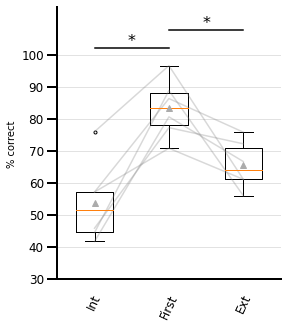

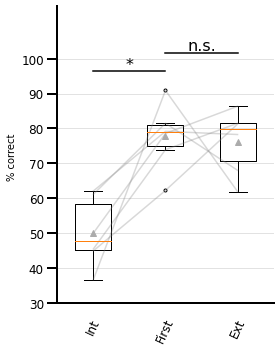

In [9]:
def int_ext_generalization():
    sessions = Session() & 'mode="experimental"' \
        & 'stage="3"'
    subjects = get_property(sessions,'animal_id')

    nr_subjects = len(subjects)
    
    
    conditions = ['gentest_1','gentest_2']
    nr_conditions = len(conditions)
    
    first_stim = ['4652','9358']
    interpolation_stim = ['6153','7076'] 
    extrapolation_stim = ['2660','16367']
    
    columns = [interpolation_stim,first_stim,extrapolation_stim]
    
    perc_correct_data = np.zeros((nr_conditions,nr_subjects,len(columns)))
    for i in range(nr_conditions):
        trainingpoint = conditions[i]
    
        # print('point',trainingpoint)
        for j in range(nr_subjects): # for each subject
            animal_id = subjects[j]
            # print('animal_id:',animal_id)
            mode,stage,_ = trainingpoint_dict[trainingpoint]
            trials = Trial() & 'mode="%s"'%mode \
                    & 'stage="%i"'%stage & 'animal_id="%s"'%animal_id 
            stimuli = trials.fetch('stimulus_id')
            responsetype = trials.fetch('responsetype')
            trialtype = trials.fetch('trialtype')
            stimuli = stimuli[trialtype=='active']
            responsetype = responsetype[trialtype=='active']
            
            for k in range(len(columns)):
                # print(columns[k])
                stimuli_bool = [True if stim in columns[k] else False for stim in stimuli]
                col_responses = responsetype[stimuli_bool]
                # print('col_responses:',len(col_responses))
                col_correct = len(col_responses[col_responses == 'correct'])
                # print('col_correct:',col_correct)
                col_value = col_correct/len(col_responses)
                perc_correct_data[i,j,k] = round(col_value*100,2)
                # print('col_value:',col_value)
                
    return perc_correct_data

def plot_int_ext_generalization():
    perc_correct_data = int_ext_generalization() # conditions x subjects x type stimuli
    comparisons = [[0,1],[1,2]]
    
    column_labels = ['Int','First', 'Ext']
    conditions = ['GT_1','GT_2']
    
    assert len(conditions) == len(perc_correct_data)
    nr_subjects = len(perc_correct_data[0])
    # box plots interpolation vs extrapolation in perc correct vs init pair
    
    for i in range(len(conditions)):
        print(conditions[i])
        fig, axs = plt.subplots()
        fig.set_figwidth(4)
        fig.set_figheight(5)
        # boxplot for each column
        axs = format_boxplot(axs,perc_correct_data[i],column_labels,
                                             y_label='% correct ',
                                         paired=True)
        axs.set_ylim([30,115])
        
        print('n = ',nr_subjects)
        
        ymax = perc_correct_data[i].max(); ymin = perc_correct_data[i].min()
        pvalues = []
        for c,comparison in enumerate(comparisons):
            col1,col2 = comparison
            if c == 0: # for comparison between interpolation and first - strict hypothesis testing 
                # is if interpolation fraction correct is less than for first stimuli
                alternative = "less"
            elif c == 1:# for comparison between first and extrapolation - strict hypothesis testing 
                # is if first stimuli fraction correct is less than for extrapolation stimuli
                alternative = "greater"

            print('t-test paired sample')
            result = ttest_rel(perc_correct_data[i,:,col1],perc_correct_data[i,:,col2],alternative=alternative)
            print(column_labels[col1],' vs ',column_labels[col2],' pvalue ..: ',round(result.pvalue,15))
            print('Wilcoxon signed rank test')
            result = wilcoxon(perc_correct_data[i,:,col1],perc_correct_data[i,:,col2],alternative=alternative)
            print(column_labels[col1],' vs ',column_labels[col2],' pvalue ..: ',round(result.pvalue,15))
        
            
            pvalues.append(round(result.pvalue,5))
            
        axs,_ = statistical_annotation(axs,comparisons,pvalues,ymax,ymin)
        
        vals_axis = list(np.arange(30,110,10))
        axs.set_yticks(vals_axis)
        labels_axis = [str(val) for val in vals_axis]
        axs.set_yticklabels(labels_axis)
        
    plt.tight_layout()
    plt.show()
    
plot_int_ext_generalization()